This notebook contians code to generate and save plots of autocorrelation functions for the lightcurves of each pulsar. It will also generate an approximate decorrelation timescale based on the lag at which the ACF drops below 0.5. The notebook finds this value using a quadratic fit, and these timescales will be saved in units of years. These metrics will be appended to a new version of a 'paper_df' csv. This notebook should be run after 'get_scintillation_data.ipynb'.

NB: This version of the notebook is meant to be run on corrected pulsar fluxes. Another version of this notebook ('make_raw_acf.ipynb') exists for raw data, and will save all plots to a different folder.

NB: This notebook currently does not determine errors associated with the polynomial fit. It should be edited to include these errors.

PRECONDITION: a folder named 'ACF_corrected' must have been created

PRECONDITION: the astroML package must be installed

IN: 'all_pulsar_measurements_corrected.csv', 'paper_dfv4.csv'

OUT: 'paper_dfv5.csv'

In [1]:
# importing required modules
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from astroML.time_series import ACF_EK

In [2]:
# setting plot preferences
%matplotlib inline
plt.rcParams['text.usetex'] = True

In [3]:
psr_df = pd.read_csv('paper_dfv4.csv')

In [4]:
#getting required information from previously made csvs
#this cell may need to be modified depending on your data
raw_psr_meas = {}
dates = {}

psr_meas_df = pd.read_csv('all_pulsar_measurements_corrected.csv')
psr_meas_df = psr_meas_df[psr_meas_df['detection']==True]  #removing nondetections

for i in psr_meas_df.index.values:
    psr_meas_df['dateobs'].loc[i] = pd.Timestamp(psr_meas_df['dateobs'].loc[i])

for name in psr_df['JNAME'].values:
    raw_psr_meas[name] = psr_meas_df[psr_meas_df['psr_name']==name]
    dates[name] = psr_meas_df[psr_meas_df['psr_name']==name]['dateobs']

dates_mjd = {name : (dates_.apply(pd.Timestamp.to_julian_date) - 2400000.5) for name, dates_ in dates.items()}

<ipython-input-33-bb7bd5c62131>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psr_meas['epoch'] = psr_meas['epoch'].apply(int)


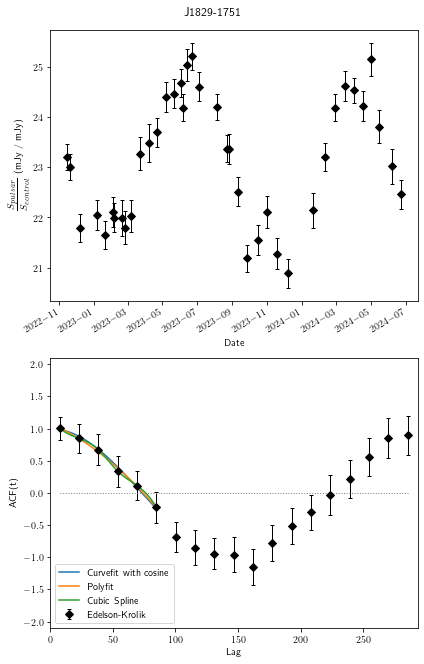

In [33]:
#gerating plots and computing timescales
inds = []
t_polyfit = []
t_polyfit_err = []
names = psr_df['JNAME'][psr_df['corrected_chi2']>100]
for name in names:
    if name=='J1803-2137':
        continue
    psr_meas = raw_psr_meas[name]
    t = dates_mjd[name] - dates_mjd[name].iloc[0]
    dy = psr_meas['rms_image']
    y_obs = psr_meas['flux_peak']
    
    #modifications to remove NA fluxes
    new_y_obs = y_obs[y_obs.notna()]
    dy = dy[y_obs.notna()]
    t = t[y_obs.notna()]
    dates[name] = dates[name][y_obs.notna()]
    y_obs = new_y_obs
    #end modifications
    
    #modifications to remove pilot epochs. This is done to remove any large changes in smaple cadence during the pilot epochs.
    if ((psr_meas['epoch'].apply(type)==str).any()): #check the datatype in the epochs field for this particular pulsar
        if psr_meas['epoch'].str.contains('3x').any():
            psr_meas.replace('3x', '3', inplace=True)
        if psr_meas['epoch'].str.contains('5x').any():
            psr_meas.replace('5x', '5', inplace=True)
        if psr_meas['epoch'].str.contains('10x').any():
            psr_meas.replace('10x', '10', inplace=True)
        psr_meas['epoch'] = psr_meas['epoch'].apply(int)
    y_obs = y_obs[psr_meas['epoch']>21]
    dy = dy[psr_meas['epoch']>21]
    t = t[psr_meas['epoch']>21]
    t = t - t.iloc[0]
    dates[name] = dates[name][psr_meas['epoch']>21]
    #end modifications

    if (y_obs.empty):
        continue

    #------------------------------------------------------------
    # compute ACF via E-K method
    C_EK, C_EK_err, bins = ACF_EK(t, y_obs, dy, bins=np.linspace(0, int(t.max()/2), int((t.max()/2)/14)))
    t_EK = 0.5 * (bins[1:] + bins[:-1])

    if (np.isnan(C_EK).any()):
        continue
    
    #------------------------------------------------------------
    # Plot the results
    fig = plt.figure(figsize=(6, 9))

    # plot the input data
    ax = fig.add_subplot(211)
    ax.errorbar(dates[name], 
                y_obs, 
                dy, 
                fmt='Dk', 
                lw=1,
                label='Pulsar',
                capsize=2
               )
    ax.set_xlabel('Date')
    ax.set_ylabel(r'$\displaystyle S_{pulsar}$ (mJy)')

    fig.autofmt_xdate()
    plt.setp(ax.get_xticklabels(), visible=True)

    # plot the ACF
    ax = fig.add_subplot(212)

    ax.errorbar(t_EK, 
                C_EK, 
                C_EK_err, 
                fmt='Dk', 
                lw=1,
                label='Edelson-Krolik',
                capsize=2
               )

    ax.plot(t_EK, 0 * t_EK, ':', lw=1, c='gray')
    
        
    #code for quadratic fit to determine decorellation timescale
    ind = 0
    for val in C_EK:
        if val < 0:
            break
        ind = ind + 1
    
    x = t_EK[:(ind+1)]
    y_raw = C_EK[:(ind+1)]
    
    num_points = 100
    x_fit = np.linspace(x[0], x[-1], num_points)

    params = np.polyfit(x, y_raw, 2)
    a = params[0]
    b = params[1]
    c = params[2]
    y_fit_polyfit = np.polyval([a,b,c], x_fit)

    plt.plot(x_fit, y_fit_polyfit, label='Polyfit')
    plt.legend()
    
    for i in np.arange(num_points):
            if y_fit_polyfit[i] < 0.5:
                #print("approximate x at which y is less than 0.5 = " + str(x_fit[i]) + " for polyfit")
                t_polyfit.append(x_fit[i])
                break
                
    inds.append(psr_df[psr_df['JNAME']==name].index[0])
    #END QUADRATIC FITTING CODE HERE

    ax.legend(loc=3)

    ax.set_xlim(0, t.max() / 2)
    ax.set_ylim(-2.1, 2.1)

    ax.set_xlabel('Lag')
    ax.set_ylabel('ACF(t)')

    fig.tight_layout()
    fig.suptitle(name, y=1.02)
    plt.savefig('ACF_corrected/' + name, bbox_inches='tight', pad_inches=0.2)
    plt.close()

In [14]:
#adding these values to the properties dataframe
psr_df['t_decorrelation_corrected'] = pd.Series(t_polyfit, index=inds) * 6 / 365
psr_df['t_decorrelation_corrected_err'] = np.nan #in the future, this line should be modified using the correlation matrix produced by numpy

In [15]:
#saving to a csv
psr_df.to_csv('paper_dfv5.csv')